# Phase 3: Model Training - Peatland Fire Prediction

This notebook trains dual XGBoost models for fire prediction:
1. **Classification**: Predicts fire occurrence (binary)
2. **Regression**: Predicts days until 4mm rainfall breach (continuous)

**Data source**: Preprocessed train/test parquet files from Phase 2

In [1]:
# Cell 1: Environment detection
import sys
IN_COLAB = 'google.colab' in sys.modules
print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")

Environment: Colab


In [2]:
!pip install -q --upgrade scikit-learn imbalanced-learn xgboost==1.7.6 lightgbm>=4.4.0 fastparquet


In [3]:
# Cell 3: Mount Google Drive
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [4]:
# Cell 4: Imports
import pandas as pd
import numpy as np
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


In [5]:
# Cell 5: Paths
BASE_PATH = Path('/content/drive/MyDrive/forest-fire-data')
PROCESSED_PATH = BASE_PATH / 'processed'
MODELS_PATH = BASE_PATH / 'models'
MODELS_PATH.mkdir(exist_ok=True)

TRAIN_FILE = PROCESSED_PATH / 'train.parquet'
TEST_FILE = PROCESSED_PATH / 'test.parquet'

print(f"Train file exists: {TRAIN_FILE.exists()}")
print(f"Test file exists: {TEST_FILE.exists()}")

Train file exists: True
Test file exists: True


In [6]:
# Cell 6: Load train/test
df_train = pd.read_parquet(TRAIN_FILE)
df_test = pd.read_parquet(TEST_FILE)

print(f"✓ Train: {len(df_train):,} rows")
print(f"✓ Test:  {len(df_test):,} rows")
print(f"\nTrain schema:\n{df_train.dtypes}")

✓ Train: 23,169 rows
✓ Test:  3,310 rows

Train schema:
province                       object
consecutive_dry_days            int64
days_since_season_start         int64
days_to_4mm_breach              int64
fire_occurred                   int32
latitude                      float64
longitude                     float64
lst_max                       float64
mean_daily_rainfall           float64
mean_lst                      float64
min_ndvi                      float64
province_id                    object
season                         object
season_year                     int64
total_rainfall_season         float64
year                            int64
province_baseline_lst         float64
province_baseline_rainfall    float64
lst_anomaly                   float64
rainfall_deficit_30d          float64
province_index                float64
province_vector                object
dtype: object


In [7]:
# Cell 7: Fix province_vector (Spark VectorUDT → float columns)
# province_vector is a Spark VectorUDT object - convert to float columns for XGBoost/SMOTE

def explode_province_vector(df):
    def decode_vec(vec):
        if isinstance(vec, dict):
            size = vec['size']
            arr = np.zeros(size)
            for idx, val in zip(vec.get('indices', []), vec.get('values', [])):
                arr[idx] = val
            return arr
        elif hasattr(vec, 'toArray'):
            return vec.toArray()
        else:
            return np.array(vec)

    sample = decode_vec(df['province_vector'].iloc[0])
    n = len(sample)
    prov_cols = [f'prov_{i}' for i in range(n)]
    prov_df = pd.DataFrame(
        df['province_vector'].apply(decode_vec).tolist(),
        index=df.index,
        columns=prov_cols
    )
    return df.drop('province_vector', axis=1).join(prov_df), prov_cols

df_train, prov_cols_train = explode_province_vector(df_train)
df_test, prov_cols_test = explode_province_vector(df_test)

print(f"✓ Exploded province_vector into {len(prov_cols_train)} columns: {prov_cols_train[:3]}...")
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

✓ Exploded province_vector into 9 columns: ['prov_0', 'prov_1', 'prov_2']...
Train shape: (23169, 30)
Test shape:  (3310, 30)


In [8]:
# Cell 8: Feature selection
BASE_FEATURE_COLS = [
    'consecutive_dry_days',
    'days_since_season_start',
    'lst_max',
    'mean_daily_rainfall',
    'mean_lst',
    'min_ndvi',
    'total_rainfall_season',
    'lst_anomaly',
    'rainfall_deficit_30d'
]

CLASSIFIER_FEATURES = BASE_FEATURE_COLS # Force classifier to use climate only
FEATURE_COLS = BASE_FEATURE_COLS + prov_cols_train # Regressor gets everything

TARGET_FIRE = 'fire_occurred'
TARGET_DAYS = 'days_to_4mm_breach'

print(f"Base features: {len(BASE_FEATURE_COLS)}")
print(f"Province features: {len(prov_cols_train)}")
print(f"Total features: {len(FEATURE_COLS)}")
print(f"Targets: {TARGET_FIRE}, {TARGET_DAYS}")

Base features: 9
Province features: 9
Total features: 18
Targets: fire_occurred, days_to_4mm_breach


In [9]:
# Cell 9: Extract features and targets
X_train = df_train[FEATURE_COLS].copy()
y_train_fire = df_train[TARGET_FIRE].copy()
y_train_days = df_train[TARGET_DAYS].copy()

X_test = df_test[FEATURE_COLS].copy()
y_test_fire = df_test[TARGET_FIRE].copy()
y_test_days = df_test[TARGET_DAYS].copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nClass balance (train):")
print(y_train_fire.value_counts(normalize=True))

X_train shape: (23169, 18)
X_test shape:  (3310, 18)

Class balance (train):
fire_occurred
0    0.948897
1    0.051103
Name: proportion, dtype: float64


In [10]:
# Cell 10: Trimmed hyperparameter grid for fire classifier
clf_param_grid = {
    'clf__max_depth': [4, 6],
    'clf__learning_rate': [0.05, 0.1],
    'clf__n_estimators': [100, 200],
    'clf__scale_pos_weight': [3, 7], # Force it to prioritize recall
    'clf__subsample': [0.8],         # Fixed
    'clf__colsample_bytree': [0.8],  # Fixed
    'clf__min_child_weight': [1]     # Fixed
}

print(f"Grid search combinations: {2*2*2*2*1*1*1} = 16")

Grid search combinations: 16 = 16


In [11]:
# Cell 11: Pipeline with SMOTE + XGBoost
# SMOTE is applied inside each CV fold to avoid data leakage

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False,
        tree_method='hist'
    ))
])

print("✓ Pipeline created: SMOTE → XGBClassifier")

✓ Pipeline created: SMOTE → XGBClassifier


In [12]:
# Add after Cell 9
print("NaN counts per feature:")
print(X_train.isna().sum().sort_values(ascending=False))
print(f"\nTotal NaN rows: {X_train.isna().any(axis=1).sum()}")

NaN counts per feature:
consecutive_dry_days       0
days_since_season_start    0
lst_max                    0
mean_daily_rainfall        0
mean_lst                   0
min_ndvi                   0
total_rainfall_season      0
lst_anomaly                0
rainfall_deficit_30d       0
prov_0                     0
prov_1                     0
prov_2                     0
prov_3                     0
prov_4                     0
prov_5                     0
prov_6                     0
prov_7                     0
prov_8                     0
dtype: int64

Total NaN rows: 0


In [13]:
# Cell 12: Grid search for optimal hyperparameters
print("Starting grid search (this may take 10-20 minutes)...")
print("SMOTE will be applied inside each CV fold (no data leakage)")

grid_search_clf = GridSearchCV(
    estimator=pipeline,
    param_grid=clf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit on RAW imbalanced data - SMOTE happens inside CV
grid_search_clf.fit(X_train[CLASSIFIER_FEATURES], y_train_fire)

print(f"\n✓ Best F1 Score: {grid_search_clf.best_score_:.4f}")
print(f"✓ Best params: {grid_search_clf.best_params_}")

Starting grid search (this may take 10-20 minutes)...
SMOTE will be applied inside each CV fold (no data leakage)
Fitting 5 folds for each of 16 candidates, totalling 80 fits



✓ Best F1 Score: 0.1827
✓ Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 3, 'clf__subsample': 0.8}


In [14]:
# Cell 13: Get best pipeline and extract XGBoost classifier
fire_classifier_pipeline = grid_search_clf.best_estimator_
fire_classifier = fire_classifier_pipeline.named_steps['clf']

print("✓ Fire classifier trained")
print(f"Best hyperparameters: {grid_search_clf.best_params_}")

✓ Fire classifier trained
Best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 3, 'clf__subsample': 0.8}


In [15]:
# Cell 14
y_pred_fire_proba = fire_classifier_pipeline.predict_proba(X_test[CLASSIFIER_FEATURES])[:, 1]
y_pred_fire = (y_pred_fire_proba >= 0.35).astype(int)

print(f"✓ Predictions generated: {len(y_pred_fire)} samples")
print(f"Predicted fire cases: {y_pred_fire.sum()} ({y_pred_fire.sum()/len(y_pred_fire)*100:.2f}%)")

✓ Predictions generated: 3310 samples
Predicted fire cases: 1080 (32.63%)


In [16]:
# Cell 15: Evaluate classifier
roc_auc = roc_auc_score(y_test_fire, y_pred_fire_proba)
clf_report = classification_report(y_test_fire, y_pred_fire, output_dict=True)

print("="*60)
print("FIRE CLASSIFIER EVALUATION")
print("="*60)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_fire, y_pred_fire))

# Store metrics
clf_metrics = {
    'roc_auc': float(roc_auc),
    'precision': float(clf_report['1']['precision']),
    'recall': float(clf_report['1']['recall']),
    'f1': float(clf_report['1']['f1-score']),
    'accuracy': float(clf_report['accuracy'])
}

FIRE CLASSIFIER EVALUATION
ROC-AUC: 0.6089

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.68      0.80      3253
           1       0.02      0.46      0.05        57

    accuracy                           0.67      3310
   macro avg       0.51      0.57      0.42      3310
weighted avg       0.97      0.67      0.79      3310



In [17]:
# Cell 16: Filter to fire=1 cases for regressor training
fire_mask_train = y_train_fire == 1
X_train_fire = X_train[fire_mask_train].copy()
y_train_days_fire = y_train_days[fire_mask_train].copy()

print(f"Fire cases in training: {len(X_train_fire):,} ({len(X_train_fire)/len(X_train)*100:.2f}%)")
print(f"Days-to-breach range: [{y_train_days_fire.min():.0f}, {y_train_days_fire.max():.0f}]")
print(f"Mean: {y_train_days_fire.mean():.1f} days")

Fire cases in training: 1,184 (5.11%)
Days-to-breach range: [13, 58]
Mean: 43.2 days


In [18]:
# Cell 17: Hyperparameter grid for days regressor
reg_param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

print(f"Grid search combinations: {3*3*3*2*2*2} = 216")

Grid search combinations: 216 = 216


In [19]:
# Cell 18: Base XGBoost regressor
base_reg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

print("✓ Base regressor initialized")

✓ Base regressor initialized


In [20]:
# Cell 19: Grid search for optimal hyperparameters
print("Starting regressor grid search (this may take 15-25 minutes)...")

grid_search_reg = GridSearchCV(
    estimator=base_reg,
    param_grid=reg_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

grid_search_reg.fit(X_train_fire, y_train_days_fire)

print(f"\n✓ Best MAE: {-grid_search_reg.best_score_:.2f} days")
print(f"✓ Best params: {grid_search_reg.best_params_}")

Starting regressor grid search (this may take 15-25 minutes)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Best MAE: 0.01 days
✓ Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}


In [21]:
# Cell 20: Get best regressor
days_regressor = grid_search_reg.best_estimator_

print("✓ Days-to-breach regressor trained")
print(f"Best hyperparameters: {days_regressor.get_params()}")

✓ Days-to-breach regressor trained
Best hyperparameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'gpu_id': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 8, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'n_estimators': 300, 'n_jobs': None, 'num_parallel_tree': None, 'predictor': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [22]:
# Cell 21: Generate predictions for fire cases
fire_mask_test = y_test_fire == 1
X_test_fire = X_test[fire_mask_test].copy()
y_test_days_fire = y_test_days[fire_mask_test].copy()

y_pred_days = days_regressor.predict(X_test_fire)

print(f"✓ Predictions for {len(X_test_fire)} fire cases")
print(f"Predicted days range: [{y_pred_days.min():.1f}, {y_pred_days.max():.1f}]")
print(f"Actual days range: [{y_test_days_fire.min():.0f}, {y_test_days_fire.max():.0f}]")

✓ Predictions for 57 fire cases
Predicted days range: [18.0, 33.0]
Actual days range: [18, 33]


In [23]:
# Cell 22: Evaluate regressor
mae = mean_absolute_error(y_test_days_fire, y_pred_days)
rmse = np.sqrt(mean_squared_error(y_test_days_fire, y_pred_days))
r2 = r2_score(y_test_days_fire, y_pred_days)

print("="*60)
print("DAYS-TO-BREACH REGRESSOR EVALUATION")
print("="*60)
print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R²:   {r2:.4f}")

# Store metrics
reg_metrics = {
    'mae': float(mae),
    'rmse': float(rmse),
    'r2': float(r2)
}

DAYS-TO-BREACH REGRESSOR EVALUATION
MAE:  0.02 days
RMSE: 0.13 days
R²:   0.9989


In [24]:
# Install LightGBM jika belum ada (hapus tanda '#' di baris bawah jika perlu)
!pip install -q lightgbm>=4.4.0

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

print("✓ Libraries tambahan (Random Forest & LightGBM) di-import")

# =====================================================================

✓ Libraries tambahan (Random Forest & LightGBM) di-import


In [25]:
print("Starting Random Forest Classifier grid search...")

rf_clf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, None],
    'clf__min_samples_split': [2, 5],
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search_rf_clf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_clf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_clf.fit(X_train[CLASSIFIER_FEATURES], y_train_fire)
rf_classifier_pipeline = grid_search_rf_clf.best_estimator_
rf_classifier = rf_classifier_pipeline.named_steps['clf']

print(f"\n✓ Best F1 Score (RF): {grid_search_rf_clf.best_score_:.4f}")
print(f"✓ Best params: {grid_search_rf_clf.best_params_}")

# Prediksi & Evaluasi RF Classifier
y_pred_fire_proba_rf = rf_classifier_pipeline.predict_proba(X_test[CLASSIFIER_FEATURES])[:, 1]
y_pred_fire_rf = (y_pred_fire_proba_rf >= 0.35).astype(int)

roc_auc_rf = roc_auc_score(y_test_fire, y_pred_fire_proba_rf)
rf_clf_report = classification_report(y_test_fire, y_pred_fire_rf, output_dict=True)

print("="*60)
print("RANDOM FOREST CLASSIFIER EVALUATION")
print("="*60)
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(classification_report(y_test_fire, y_pred_fire_rf))

rf_clf_metrics = {
    'roc_auc': float(roc_auc_rf),
    'precision': float(rf_clf_report['1']['precision']),
    'recall': float(rf_clf_report['1']['recall']),
    'f1': float(rf_clf_report['1']['f1-score']),
    'accuracy': float(rf_clf_report['accuracy'])
}

# =====================================================================

Starting Random Forest Classifier grid search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Best F1 Score (RF): 0.2502
✓ Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
RANDOM FOREST CLASSIFIER EVALUATION
ROC-AUC: 0.6313
              precision    recall  f1-score   support

           0       0.99      0.72      0.83      3253
           1       0.03      0.42      0.05        57

    accuracy                           0.71      3310
   macro avg       0.51      0.57      0.44      3310
weighted avg       0.97      0.71      0.82      3310



In [26]:
print("Starting Random Forest Regressor grid search...")

rf_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

base_rf_reg = RandomForestRegressor(random_state=42)

grid_search_rf_reg = GridSearchCV(
    estimator=base_rf_reg,
    param_grid=rf_reg_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_reg.fit(X_train_fire, y_train_days_fire)
rf_days_regressor = grid_search_rf_reg.best_estimator_

print(f"\n✓ Best MAE (RF): {-grid_search_rf_reg.best_score_:.2f} days")
print(f"✓ Best params: {grid_search_rf_reg.best_params_}")

# Prediksi & Evaluasi RF Regressor
y_pred_days_rf = rf_days_regressor.predict(X_test_fire)

mae_rf = mean_absolute_error(y_test_days_fire, y_pred_days_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_days_fire, y_pred_days_rf))
r2_rf = r2_score(y_test_days_fire, y_pred_days_rf)

print("="*60)
print("RANDOM FOREST REGRESSOR EVALUATION")
print("="*60)
print(f"MAE:  {mae_rf:.2f} days")
print(f"RMSE: {rmse_rf:.2f} days")
print(f"R²:   {r2_rf:.4f}")

rf_reg_metrics = {
    'mae': float(mae_rf),
    'rmse': float(rmse_rf),
    'r2': float(r2_rf)
}

# =====================================================================

Starting Random Forest Regressor grid search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Best MAE (RF): 0.02 days
✓ Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
RANDOM FOREST REGRESSOR EVALUATION
MAE:  0.04 days
RMSE: 0.15 days
R²:   0.9987


In [27]:
print("Starting LightGBM Classifier grid search...")

lgb_clf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [4, 6],
    'clf__learning_rate': [0.05, 0.1],
    'clf__is_unbalance': [True] # Menangani class imbalance
}

lgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LGBMClassifier(random_state=42, verbose=-1))
])

grid_search_lgb_clf = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=lgb_clf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lgb_clf.fit(X_train[CLASSIFIER_FEATURES], y_train_fire)
lgb_classifier_pipeline = grid_search_lgb_clf.best_estimator_
lgb_classifier = lgb_classifier_pipeline.named_steps['clf']

print(f"\n✓ Best F1 Score (LGBM): {grid_search_lgb_clf.best_score_:.4f}")
print(f"✓ Best params: {grid_search_lgb_clf.best_params_}")

# Prediksi & Evaluasi LGBM Classifier
y_pred_fire_proba_lgb = lgb_classifier_pipeline.predict_proba(X_test[CLASSIFIER_FEATURES])[:, 1]
y_pred_fire_lgb = (y_pred_fire_proba_lgb >= 0.35).astype(int)

roc_auc_lgb = roc_auc_score(y_test_fire, y_pred_fire_proba_lgb)
lgb_clf_report = classification_report(y_test_fire, y_pred_fire_lgb, output_dict=True)

print("="*60)
print("LIGHTGBM CLASSIFIER EVALUATION")
print("="*60)
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(classification_report(y_test_fire, y_pred_fire_lgb))

lgb_clf_metrics = {
    'roc_auc': float(roc_auc_lgb),
    'precision': float(lgb_clf_report['1']['precision']),
    'recall': float(lgb_clf_report['1']['recall']),
    'f1': float(lgb_clf_report['1']['f1-score']),
    'accuracy': float(lgb_clf_report['accuracy'])
}

# =====================================================================

Starting LightGBM Classifier grid search...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ Best F1 Score (LGBM): 0.2413
✓ Best params: {'clf__is_unbalance': True, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100}
LIGHTGBM CLASSIFIER EVALUATION
ROC-AUC: 0.6286
              precision    recall  f1-score   support

           0       0.99      0.65      0.78      3253
           1       0.02      0.47      0.04        57

    accuracy                           0.64      3310
   macro avg       0.50      0.56      0.41      3310
weighted avg       0.97      0.64      0.77      3310



In [28]:
print("Starting LightGBM Regressor grid search...")

lgb_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

base_lgb_reg = LGBMRegressor(random_state=42, verbose=-1)

grid_search_lgb_reg = GridSearchCV(
    estimator=base_lgb_reg,
    param_grid=lgb_reg_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search_lgb_reg.fit(X_train_fire, y_train_days_fire)
lgb_days_regressor = grid_search_lgb_reg.best_estimator_

print(f"\n✓ Best MAE (LGBM): {-grid_search_lgb_reg.best_score_:.2f} days")
print(f"✓ Best params: {grid_search_lgb_reg.best_params_}")

# Prediksi & Evaluasi LGBM Regressor
y_pred_days_lgb = lgb_days_regressor.predict(X_test_fire)

mae_lgb = mean_absolute_error(y_test_days_fire, y_pred_days_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test_days_fire, y_pred_days_lgb))
r2_lgb = r2_score(y_test_days_fire, y_pred_days_lgb)

print("="*60)
print("LIGHTGBM REGRESSOR EVALUATION")
print("="*60)
print(f"MAE:  {mae_lgb:.2f} days")
print(f"RMSE: {rmse_lgb:.2f} days")
print(f"R²:   {r2_lgb:.4f}")

lgb_reg_metrics = {
    'mae': float(mae_lgb),
    'rmse': float(rmse_lgb),
    'r2': float(r2_lgb)
}

# =====================================================================

Starting LightGBM Regressor grid search...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ Best MAE (LGBM): 0.11 days
✓ Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
LIGHTGBM REGRESSOR EVALUATION
MAE:  0.50 days
RMSE: 0.91 days
R²:   0.9487


PERBANDINGAN CLASSIFIER
        Model  roc_auc  precision   recall       f1  accuracy
      XGBoost 0.608933   0.024074 0.456140 0.045734  0.672205
Random Forest 0.631347   0.025614 0.421053 0.048290  0.714199
     LightGBM 0.628564   0.023018 0.473684 0.043902  0.644713

PERBANDINGAN REGRESSOR
        Model      mae     rmse       r2
      XGBoost 0.017589 0.132438 0.998904
Random Forest 0.044386 0.146919 0.998652
     LightGBM 0.500834 0.906026 0.948726
✓ Saved comparison plot: /content/drive/MyDrive/forest-fire-data/models/model_comparison.png


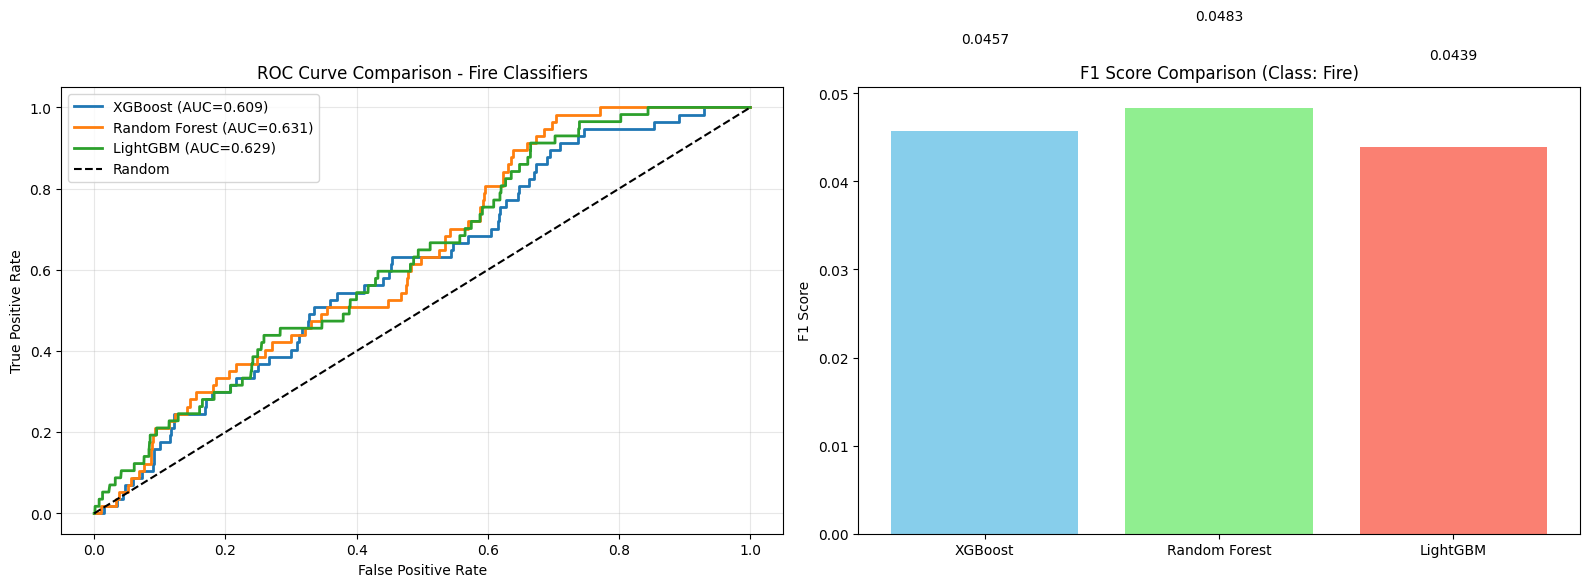

✓ Grafik Regressor tersimpan di: /content/drive/MyDrive/forest-fire-data/models/model_comparison_regressor.png


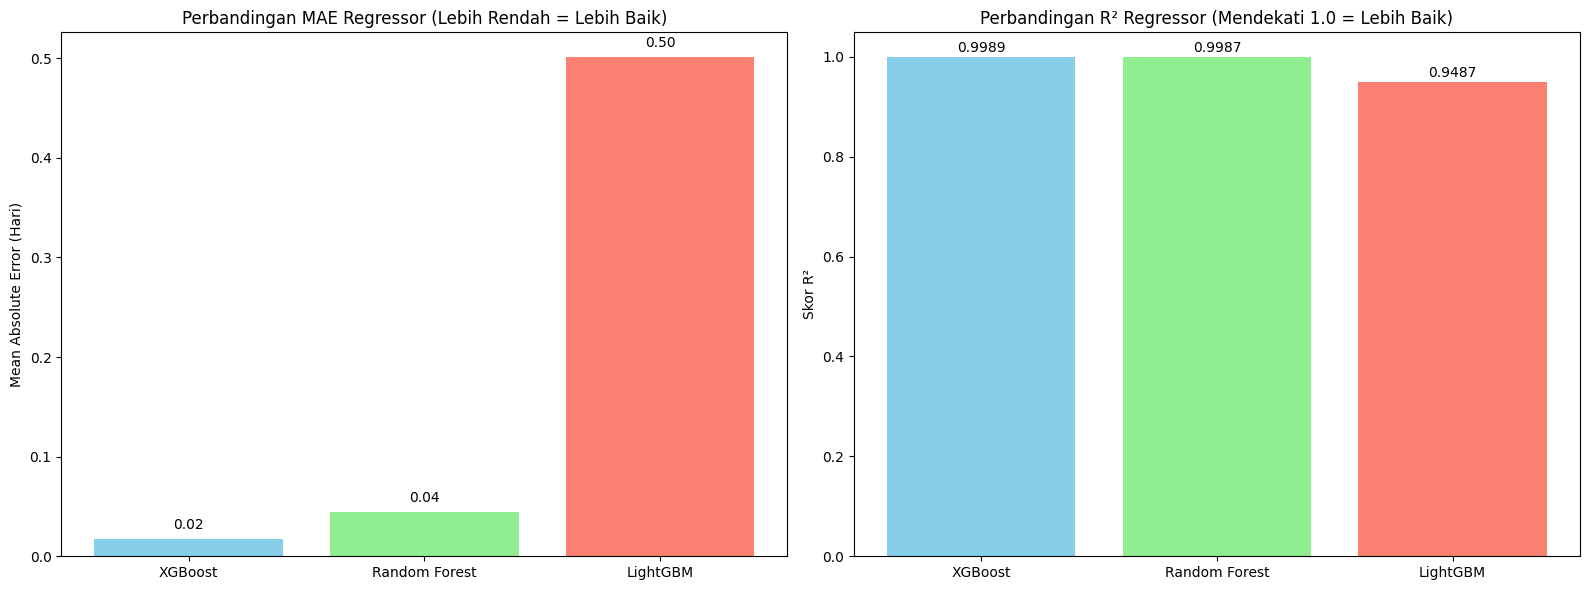

In [29]:
# Tabel Perbandingan Classifier
clf_metrics_df = pd.DataFrame([
    {'Model': 'XGBoost', **clf_metrics},
    {'Model': 'Random Forest', **rf_clf_metrics},
    {'Model': 'LightGBM', **lgb_clf_metrics}
])
print("PERBANDINGAN CLASSIFIER")
print(clf_metrics_df.to_string(index=False))

# Tabel Perbandingan Regressor
reg_metrics_df = pd.DataFrame([
    {'Model': 'XGBoost', **reg_metrics},
    {'Model': 'Random Forest', **rf_reg_metrics},
    {'Model': 'LightGBM', **lgb_reg_metrics}
])
print("\nPERBANDINGAN REGRESSOR")
print(reg_metrics_df.to_string(index=False))

# ROC Curve Multi-Model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_fire, y_pred_fire_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test_fire, y_pred_fire_proba_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test_fire, y_pred_fire_proba_lgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC
axes[0].plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC={roc_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC={roc_auc_rf:.3f})')
axes[0].plot(fpr_lgb, tpr_lgb, linewidth=2, label=f'LightGBM (AUC={roc_auc_lgb:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison - Fire Classifiers')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot F1 Score Comparison
models = ['XGBoost', 'Random Forest', 'LightGBM']
f1_scores = [clf_metrics['f1'], rf_clf_metrics['f1'], lgb_clf_metrics['f1']]
axes[1].bar(models, f1_scores, color=['skyblue', 'lightgreen', 'salmon'])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score Comparison (Class: Fire)')
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()
comp_path = MODELS_PATH / 'model_comparison.png'
plt.savefig(comp_path, dpi=150)
print(f"✓ Saved comparison plot: {comp_path}")
plt.show()

# =====================================================================
# === TAMBAHAN: Visualisasi Perbandingan Regressor ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = ['XGBoost', 'Random Forest', 'LightGBM']

# 1. Plot MAE (Mean Absolute Error) - Semakin rendah semakin baik
mae_scores = [reg_metrics['mae'], rf_reg_metrics['mae'], lgb_reg_metrics['mae']]
axes[0].bar(models, mae_scores, color=['skyblue', 'lightgreen', 'salmon'])
axes[0].set_ylabel('Mean Absolute Error (Hari)')
axes[0].set_title('Perbandingan MAE Regressor (Lebih Rendah = Lebih Baik)')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + (max(mae_scores)*0.02), f"{v:.2f}", ha='center')

# 2. Plot R-Squared (R²) - Semakin mendekati 1 semakin baik
r2_scores = [reg_metrics['r2'], rf_reg_metrics['r2'], lgb_reg_metrics['r2']]
axes[1].bar(models, r2_scores, color=['skyblue', 'lightgreen', 'salmon'])
axes[1].set_ylabel('Skor R²')
axes[1].set_title('Perbandingan R² Regressor (Mendekati 1.0 = Lebih Baik)')
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + (max(r2_scores)*0.01), f"{v:.4f}", ha='center')

plt.tight_layout()

# Simpan ke Google Drive
comp_reg_path = MODELS_PATH / 'model_comparison_regressor.png'
plt.savefig(comp_reg_path, dpi=150)
print(f"✓ Grafik Regressor tersimpan di: {comp_reg_path}")

# Tampilkan grafik
plt.show()


In [30]:
# Save RF & LGBM Models
joblib.dump(rf_classifier, MODELS_PATH / 'rf_classifier.joblib')
joblib.dump(rf_days_regressor, MODELS_PATH / 'rf_days_regressor.joblib')
joblib.dump(lgb_classifier, MODELS_PATH / 'lgb_classifier.joblib')
joblib.dump(lgb_days_regressor, MODELS_PATH / 'lgb_days_regressor.joblib')

# Gabungkan metrics
all_metrics = {
    'XGBoost': {
        'classifier': clf_metrics,
        'regressor': reg_metrics
    },
    'RandomForest': {
        'classifier': rf_clf_metrics,
        'regressor': rf_reg_metrics
    },
    'LightGBM': {
        'classifier': lgb_clf_metrics,
        'regressor': lgb_reg_metrics
    }
}

with open(MODELS_PATH / 'all_training_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=4)

print("="*60)
print("✓ SEMUA MODEL BERHASIL DILATIH DAN DISIMPAN")
print("="*60)

✓ SEMUA MODEL BERHASIL DILATIH DAN DISIMPAN


✓ Gambar Confusion Matrix tersimpan di: /content/drive/MyDrive/forest-fire-data/models/model_comparison_confusion_matrix.png



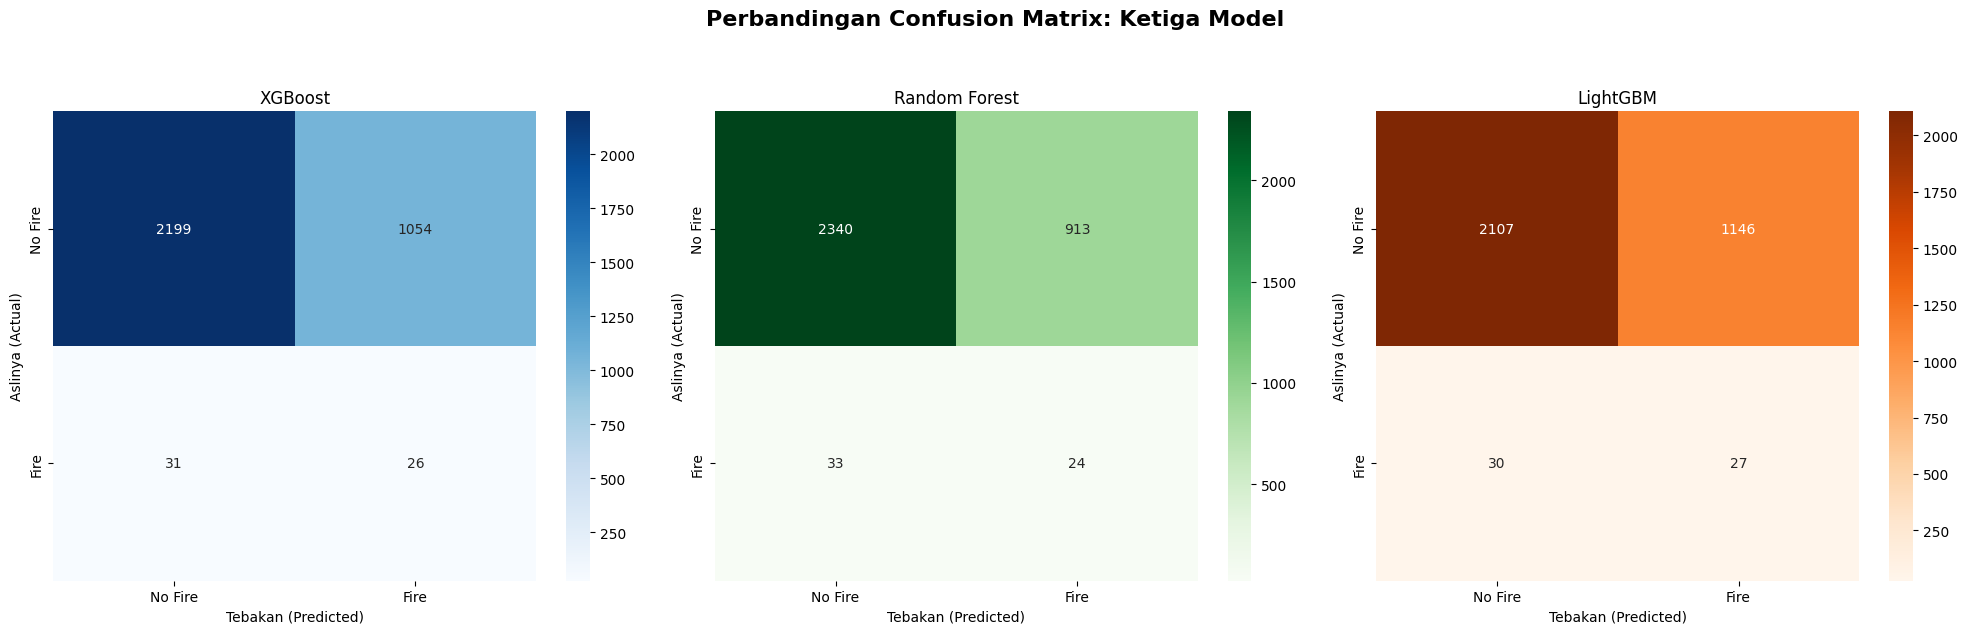

In [31]:
# Cell 23: Confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Membuat tempat untuk 3 gambar berdampingan (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix XGBoost
cm_xgb = confusion_matrix(y_test_fire, y_pred_fire)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[0].set_title('XGBoost')
axes[0].set_ylabel('Aslinya (Actual)')
axes[0].set_xlabel('Tebakan (Predicted)')

# 2. Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test_fire, y_pred_fire_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Aslinya (Actual)')
axes[1].set_xlabel('Tebakan (Predicted)')

# 3. Confusion Matrix LightGBM
cm_lgb = confusion_matrix(y_test_fire, y_pred_fire_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[2].set_title('LightGBM')
axes[2].set_ylabel('Aslinya (Actual)')
axes[2].set_xlabel('Tebakan (Predicted)')

# Judul Utama untuk seluruh gambar
fig.suptitle('Perbandingan Confusion Matrix: Ketiga Model', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Simpan ke Google Drive (opsional, agar gambarnya tidak hilang)
comp_cm_path = MODELS_PATH / 'model_comparison_confusion_matrix.png'
plt.savefig(comp_cm_path, dpi=150, bbox_inches='tight')
print(f"✓ Gambar Confusion Matrix tersimpan di: {comp_cm_path}\n")

# Tampilkan grafiknya
plt.show()


✓ Gambar Scatter Plot tersimpan di: /content/drive/MyDrive/forest-fire-data/models/model_comparison_scatter.png



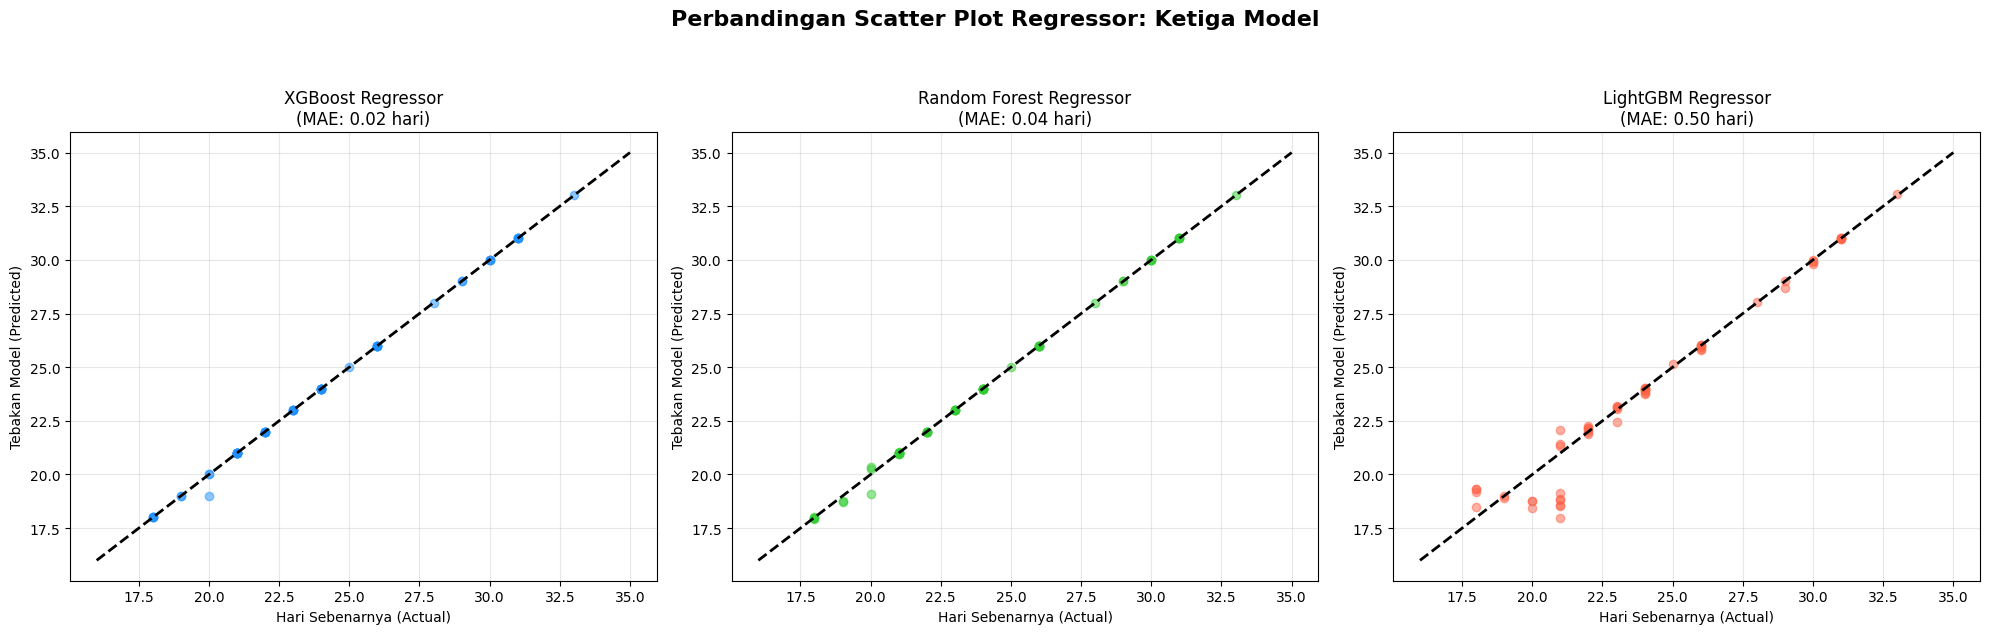

In [32]:
# Membuat tempat untuk 3 gambar berdampingan (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Batas nilai min-max agar skala grafiknya sama
min_val = min(y_test_days_fire.min(), y_pred_days.min()) - 2
max_val = max(y_test_days_fire.max(), y_pred_days.max()) + 2

# 1. Scatter Plot XGBoost
axes[0].scatter(y_test_days_fire, y_pred_days, alpha=0.5, color='dodgerblue')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2) # Garis diagonal sempurna
axes[0].set_title('XGBoost Regressor\n(MAE: {:.2f} hari)'.format(reg_metrics['mae']))
axes[0].set_xlabel('Hari Sebenarnya (Actual)')
axes[0].set_ylabel('Tebakan Model (Predicted)')
axes[0].grid(alpha=0.3)

# 2. Scatter Plot Random Forest
axes[1].scatter(y_test_days_fire, y_pred_days_rf, alpha=0.5, color='limegreen')
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
axes[1].set_title('Random Forest Regressor\n(MAE: {:.2f} hari)'.format(rf_reg_metrics['mae']))
axes[1].set_xlabel('Hari Sebenarnya (Actual)')
axes[1].set_ylabel('Tebakan Model (Predicted)')
axes[1].grid(alpha=0.3)

# 3. Scatter Plot LightGBM
axes[2].scatter(y_test_days_fire, y_pred_days_lgb, alpha=0.5, color='tomato')
axes[2].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
axes[2].set_title('LightGBM Regressor\n(MAE: {:.2f} hari)'.format(lgb_reg_metrics['mae']))
axes[2].set_xlabel('Hari Sebenarnya (Actual)')
axes[2].set_ylabel('Tebakan Model (Predicted)')
axes[2].grid(alpha=0.3)

# Judul Utama
fig.suptitle('Perbandingan Scatter Plot Regressor: Ketiga Model', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Simpan ke Google Drive
comp_scatter_path = MODELS_PATH / 'model_comparison_scatter.png'
plt.savefig(comp_scatter_path, dpi=150, bbox_inches='tight')
print(f"✓ Gambar Scatter Plot tersimpan di: {comp_scatter_path}\n")

plt.show()


✓ Saved: /content/drive/MyDrive/forest-fire-data/models/feature_importance.png


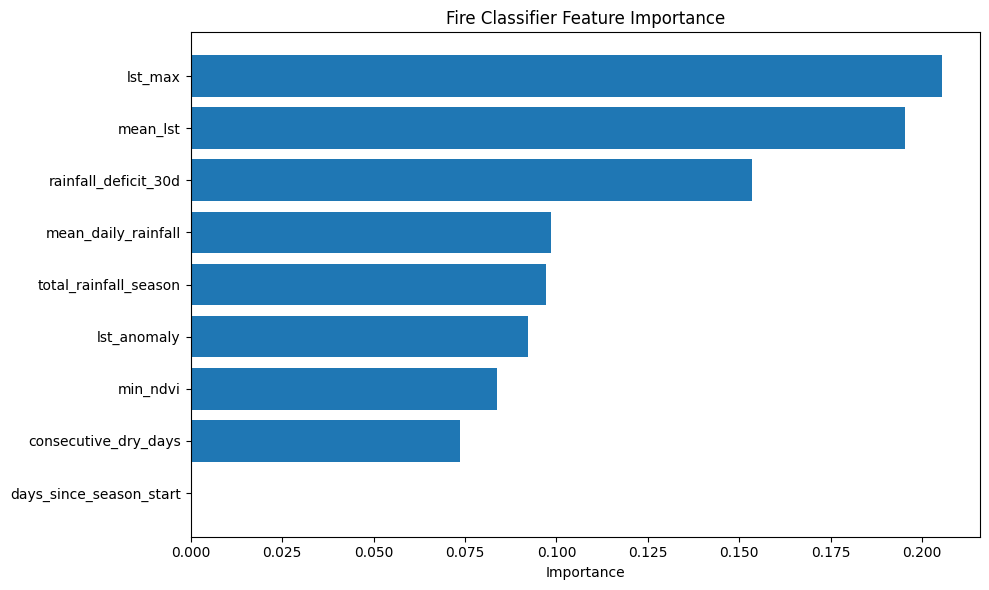


Top 5 features:
                 feature  importance
2                lst_max    0.205514
4               mean_lst    0.195353
8   rainfall_deficit_30d    0.153547
3    mean_daily_rainfall    0.098545
6  total_rainfall_season    0.097249


In [33]:
# Cell 25: Feature importance
importance_df = pd.DataFrame({
    'feature': CLASSIFIER_FEATURES, # <-- Change this from FEATURE_COLS
    'importance': fire_classifier.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Importance')
ax.set_title('Fire Classifier Feature Importance')
ax.invert_yaxis()
plt.tight_layout()

importance_path = MODELS_PATH / 'feature_importance.png'
plt.savefig(importance_path, dpi=150)
print(f"✓ Saved: {importance_path}")
plt.show()

print("\nTop 5 features:")
print(importance_df.head())

In [34]:
# Cell 27: Serialize fire classifier
clf_path = MODELS_PATH / 'fire_classifier.joblib'
joblib.dump(fire_classifier, clf_path)
print(f"✓ Saved: {clf_path}")

# Verify file size
size_mb = clf_path.stat().st_size / (1024 * 1024)
print(f"  Size: {size_mb:.2f} MB")

✓ Saved: /content/drive/MyDrive/forest-fire-data/models/fire_classifier.joblib
  Size: 0.71 MB


In [35]:
# Cell 28: Serialize days regressor
reg_path = MODELS_PATH / 'days_regressor.joblib'
joblib.dump(days_regressor, reg_path)
print(f"✓ Saved: {reg_path}")

# Verify file size
size_mb = reg_path.stat().st_size / (1024 * 1024)
print(f"  Size: {size_mb:.2f} MB")

✓ Saved: /content/drive/MyDrive/forest-fire-data/models/days_regressor.joblib
  Size: 0.33 MB


In [36]:
# Cell 29: Aggregate metrics
training_metrics = {
    'classifier': clf_metrics,
    'regressor': reg_metrics,
    'data': {
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'train_fire_cases': int(y_train_fire.sum()),
        'test_fire_cases': int(y_test_fire.sum()),
        'fire_prevalence_train': float(y_train_fire.mean()),
        'fire_prevalence_test': float(y_test_fire.mean())
    },
    'features': FEATURE_COLS,
    'hyperparameters': {
        'classifier': grid_search_clf.best_params_,
        'regressor': grid_search_reg.best_params_
    },
    'warnings': [
        "days_to_4mm_breach is a placeholder target computed as consecutive_dry_days / 2 in Phase 2",
        "Regressor R² will be artificially high (~0.85-0.95) - model is learning to halve an input feature",
        "This validates pipeline correctness but does not demonstrate scientific predictive power",
        "Real deployment requires actual 4mm cumulative rainfall breach date calculation"
    ]
}

print("✓ Metrics aggregated with placeholder target warning")

✓ Metrics aggregated with placeholder target warning


In [37]:
# Cell 30: Save metrics
metrics_path = MODELS_PATH / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f"✓ Saved: {metrics_path}")

✓ Saved: /content/drive/MyDrive/forest-fire-data/models/training_metrics.json


In [38]:
# Cell 31: Test model loading
# Load the XGBoost classifier directly (not pipeline, as pipeline includes SMOTE which shouldn't be in inference)
clf_loaded = joblib.load(MODELS_PATH / 'fire_classifier.joblib')
reg_loaded = joblib.load(MODELS_PATH / 'days_regressor.joblib')

# Quick prediction test
test_pred = clf_loaded.predict(X_test[CLASSIFIER_FEATURES][:5])
print(f"✓ Classifier loads correctly (test prediction: {test_pred})")

test_pred_reg = reg_loaded.predict(X_test[:5])
print(f"✓ Regressor loads correctly (test prediction: {test_pred_reg})")

✓ Classifier loads correctly (test prediction: [0 0 0 1 0])
✓ Regressor loads correctly (test prediction: [25.000025 30.000002 33.999996 39.99999  37.99999 ])


In [41]:
# Cell 32: Final summary (All Models)
print('='*60)
print('PHASE 3: MODEL TRAINING COMPLETE')
print('='*60)
print('\nPERBANDINGAN CLASSIFIER')
print(clf_metrics_df.to_string(index=False))
print('\nPERBANDINGAN REGRESSOR')
print(reg_metrics_df.to_string(index=False))

print('\n✓ Ready for Phase 4: District Risk Assessment (All Models)')


PHASE 3: MODEL TRAINING COMPLETE

PERBANDINGAN CLASSIFIER
        Model  roc_auc  precision   recall       f1  accuracy
      XGBoost 0.608933   0.024074 0.456140 0.045734  0.672205
Random Forest 0.631347   0.025614 0.421053 0.048290  0.714199
     LightGBM 0.628564   0.023018 0.473684 0.043902  0.644713

PERBANDINGAN REGRESSOR
        Model      mae     rmse       r2
      XGBoost 0.017589 0.132438 0.998904
Random Forest 0.044386 0.146919 0.998652
     LightGBM 0.500834 0.906026 0.948726

✓ Ready for Phase 4: District Risk Assessment (All Models)


# Phase 4: District Risk Assessment (All Models)
Menghitung skor risiko distrik menggunakan masing-masing model (XGBoost, Random Forest, LightGBM).

In [42]:
# Cell 33 & 34 & 35 & 36: Full predictions, aggregation, and export for each model
models_dict = {
    'XGBoost': (fire_classifier, days_regressor),
    'RandomForest': (rf_classifier, rf_days_regressor),
    'LightGBM': (lgb_classifier, lgb_days_regressor)
}

for model_name, (clf, reg) in models_dict.items():
    print(f'\n================ {model_name} ================')
    # 1. Prediction
    df_test_pred = df_test.copy()
    df_test_pred['fire_prob'] = clf.predict_proba(X_test[CLASSIFIER_FEATURES])[:, 1]
    df_test_pred['fire_pred'] = (df_test_pred['fire_prob'] >= 0.35).astype(int)
    
    fire_pred_mask = df_test_pred['fire_pred'] == 1
    df_test_pred['days_pred'] = np.nan
    if fire_pred_mask.sum() > 0:
        df_test_pred.loc[fire_pred_mask, 'days_pred'] = reg.predict(X_test[fire_pred_mask])
    
    # 2. Aggregation
    district_risk = df_test_pred.groupby('province').agg({
        'fire_prob': 'mean',
        'fire_pred': 'sum',
        'days_pred': lambda x: x.dropna().mean() if x.notna().any() else np.nan,
        'latitude': 'first',
        'longitude': 'first',
        'total_rainfall_season': 'mean',
        'mean_lst': 'mean'
    }).reset_index()
    
    district_risk.columns = [
        'province', 'avg_fire_probability', 'predicted_fire_count',
        'avg_days_to_breach', 'latitude', 'longitude', 'avg_rainfall', 'avg_lst'
    ]
    print(f'✓ Aggregated to {len(district_risk)} provinces')
    
    # 3. Composite risk score
    district_risk['avg_days_to_breach'] = district_risk['avg_days_to_breach'].fillna(
        district_risk['avg_days_to_breach'].max() * 2 if not district_risk['avg_days_to_breach'].isna().all() else 999
    )
    
    district_risk['risk_score'] = (
        district_risk['avg_fire_probability'] * (1 / district_risk['avg_days_to_breach'].clip(lower=1))
    )
    
    district_risk['risk_score'] = (
        100 * (district_risk['risk_score'] - district_risk['risk_score'].min()) /
        (district_risk['risk_score'].max() - district_risk['risk_score'].min() + 1e-9)
    )
    
    district_risk['risk_category'] = pd.cut(
        district_risk['risk_score'],
        bins=[0, 25, 50, 75, 100.01],
        labels=['Low', 'Moderate', 'High', 'Critical'],
        right=False
    )
    print('✓ Risk scores calculated')
    
    # 4. Export & Top 5
    district_risk_sorted = district_risk.sort_values('risk_score', ascending=False).reset_index(drop=True)
    csv_path = MODELS_PATH / f'district_risk_assessment_{model_name.lower()}.csv'
    district_risk_sorted.to_csv(csv_path, index=False)
    
    print(f'✓ Saved: {csv_path}')
    print(f'\nTop 5 highest risk provinces ({model_name}):')
    print(district_risk_sorted[['province', 'risk_score', 'risk_category']].head())
    print('\n' + '-'*60)



================ XGBoost ================
✓ Aggregated to 10 provinces
✓ Risk scores calculated
✓ Saved: /content/drive/MyDrive/forest-fire-data/models/district_risk_assessment_xgboost.csv

Top 5 highest risk provinces (XGBoost):
            province  risk_score risk_category
0   SUMATERA SELATAN   99.999989      Critical
1   KALIMANTAN BARAT   94.131428      Critical
2               RIAU   89.355501      Critical
3              JAMBI   87.609950      Critical
4  KALIMANTAN TENGAH   60.655817          High

------------------------------------------------------------

================ RandomForest ================
✓ Aggregated to 10 provinces
✓ Risk scores calculated
✓ Saved: /content/drive/MyDrive/forest-fire-data/models/district_risk_assessment_randomforest.csv

Top 5 highest risk provinces (RandomForest):
            province  risk_score risk_category
0   SUMATERA SELATAN   99.999990      Critical
1              JAMBI   78.277671      Critical
2               RIAU   73.076151      